# Implementação do método de Zhang et al. para o **Case 2** do artigo-base

Aluno: José Tayrone Santos de Oliveira

---

O objetivo é implementar e analisar a metodologia do artigo  
   "On the Identification of Noise Covariances and Adaptive Kalman Filtering: A New Look at a 50 Year-Old Problem"

---

Os passos são:

- simular o sistema linear do Case 2;
- rodar um filtro subótimo para gerar a sequência de inovações;
- estimar as autocovariâncias amostrais da inovação;
- encontrar o ganho estacionário $W$ minimizando as correlações defasadas da inovação;
- estimar $R$ a partir dos post-fit residuals;
- estimar $q$ (ruído escalar de processo) e a matriz $P$ iterativamente;
- verificar o resultado com diagnósticos

## 1. Importações e configuração

In [125]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy.stats import chi2

from numpy.linalg import eigvals, inv, pinv, norm

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(12345)

## 2. Sistema do Case 2

$$
x(k)=
\begin{bmatrix}
0.8 & 1 \\
-0.4 & 0
\end{bmatrix}
x(k-1)
+
\begin{bmatrix}
1 \\
0.5
\end{bmatrix}
v(k-1),
\qquad
z(k)=
\begin{bmatrix}
1 & 0
\end{bmatrix}
x(k)+w(k)
$$

com:

- $v(k)\sim \mathcal N(0,q)$,
- $w(k)\sim \mathcal N(0,r)$.

Usando:

- $q_{	ext{true}} = 1$
- $r_{	ext{true}} = 1$

Vamos calcular o ganho de Kalman estacionário verdadeiro a partir da equação de Riccati, apenas para comparar com a estimativa produzida pelo método

In [126]:
F = np.array([[0.8, 1.0],
              [-0.4, 0.0]])

Gamma = np.array([[1.0],
                  [0.5]])

H = np.array([[1.0, 0.0]])

q_true = 1.0
r_true = 1.0

Qx_true = Gamma @ np.array([[q_true]]) @ Gamma.T
R_true = np.array([[r_true]])

Pbar_true = la.solve_discrete_are(F.T, H.T, Qx_true, R_true)
S_true = H @ Pbar_true @ H.T + R_true
W_true = Pbar_true @ H.T @ np.linalg.inv(S_true)

print("F =\n", F)
print("\nGamma =\n", Gamma)
print("\nH =\n", H)
print("\nq_true =", q_true)
print("r_true =", r_true)
print("\nW_true =\n", W_true)
print("\nS_true =\n", S_true)

F =
 [[ 0.8  1. ]
 [-0.4  0. ]]

Gamma =
 [[1. ]
 [0.5]]

H =
 [[1. 0.]]

q_true = 1.0
r_true = 1.0

W_true =
 [[0.6542]
 [0.0883]]

S_true =
 [[2.8921]]


## 3. Simulação do sistema

### Convenção
- primeiro o estado evolui;
- depois a medição observa o novo estado

Ou seja, neste notebook:
- $x_{k+1} = F x_k + \Gamma v_k$
- $z_k = H x_{k+1} + w_k$

In [ ]:
def simulate_linear_system(F, Gamma, H, q, r, N, rng):
    n = F.shape[0]
    x = np.zeros((N, n))
    z = np.zeros(N)

    h = H.ravel()
    g = Gamma[:, 0]

    for k in range(1, N):
        v = rng.normal(scale=np.sqrt(q))
        w = rng.normal(scale=np.sqrt(r))

        x[k] = F @ x[k - 1] + g * v
        z[k] = h @ x[k] + w

    z[0] = h @ x[0] + rng.normal(scale=np.sqrt(r))
    
    return x, z

N = 12_000
x_true, z = simulate_linear_system(F, Gamma, H, q_true, r_true, N, rng)

print("Formato de x_true:", x_true.shape)
print("Formato de z:", z.shape)

Formato de x_true: (12000, 2)
Formato de z: (12000,)


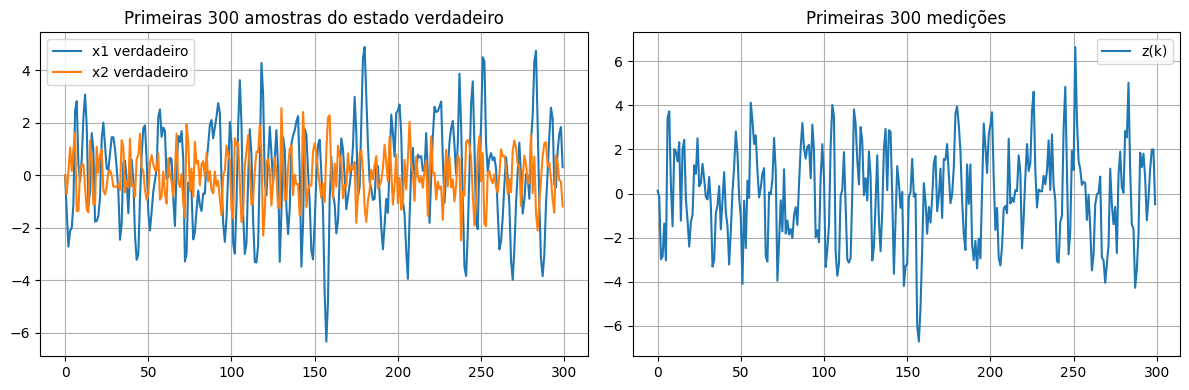

In [128]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x_true[:300, 0], label="x1 verdadeiro")
ax[0].plot(x_true[:300, 1], label="x2 verdadeiro")
ax[0].set_title("Primeiras 300 amostras do estado verdadeiro")
ax[0].legend()

ax[1].plot(z[:300], label="z(k)")
ax[1].set_title("Primeiras 300 medições")
ax[1].legend()

plt.tight_layout()
plt.show()

## 4. Filtro estacionário com ganho fixo

Implementação do filtro de ganho fixo:

$$
\hat x_{k|k-1} = F \hat x_{k-1|k-1}
$$

$$
u_k = z_k - H \hat x_{k|k-1}
$$

$$
\hat x_{k|k} = \hat x_{k|k-1} + W 
u_k
$$

**post-fit residual**:

$$
\mu_k = z_k - H \hat x_{k|k}
$$

In [ ]:
def run_filter_scalar(F, H, W, z, x0=None):
    n = F.shape[0]
    N = len(z)

    x_upd = np.zeros(n) if x0 is None else np.array(x0, dtype=float).ravel().copy()

    x_pred_hist = np.zeros((N, n))
    x_upd_hist = np.zeros((N, n))
    nu = np.zeros(N)
    mu = np.zeros(N)

    h = H.ravel()
    K = np.array(W, dtype=float).ravel()

    for k in range(N):
        x_pred = F @ x_upd
        innovation = z[k] - h @ x_pred
        x_upd = x_pred + K * innovation
        post_fit = z[k] - h @ x_upd

        x_pred_hist[k] = x_pred
        x_upd_hist[k] = x_upd
        nu[k] = innovation
        mu[k] = post_fit

    return x_pred_hist, x_upd_hist, nu, mu

W0 = np.array([[0.9],[0.5]])

_, _, nu0, mu0 = run_filter_scalar(F, H, W0, z)

print("W0 =\n", W0)
print("\nMédia da inovação com W0:", np.mean(nu0))
print("Variância da inovação com W0:", np.var(nu0))

W0 =
 [[0.9]
 [0.5]]

Média da inovação com W0: 0.015413397646871364
Variância da inovação com W0: 4.252419295968952


## 5. Autocovariâncias amostrais da inovação

Cada autocovariância $C_i$ será escalar porque a medição é escalar:

$$
\hat C_i =
\frac{1}{N-i}\sum_{k=i}^{N-1} u_k\,u_{k-i}
$$

Se o ganho estiver próximo do ótimo, as inovações tendem a ficar mais brancas, ou seja, os termos $\hat C_i$ para $i>0$ tendem a diminuir

In [ ]:
def innovation_covariances_scalar(nu, M):
    C = np.empty(M)
    C[0] = np.mean(nu * nu)
    for i in range(1, M):
        C[i] = np.mean(nu[i:] * nu[:-i])
    return C

def objective_J_scalar(C):
    C0 = max(C[0], 1e-12)
    return 0.5 * np.sum((C[1:] ** 2) / (C0 ** 2))

M = 100
C0 = innovation_covariances_scalar(nu0[300:], M)
J0 = objective_J_scalar(C0)

print("Primeiras autocovariâncias com W0:\n", C0[:8])
print("\nJ(W0) =", J0)

Primeiras autocovariâncias com W0:
 [ 4.2501 -2.4397  1.2622 -0.4441  0.1276 -0.0366 -0.0182  0.079 ]

J(W0) = 0.22005699772135937


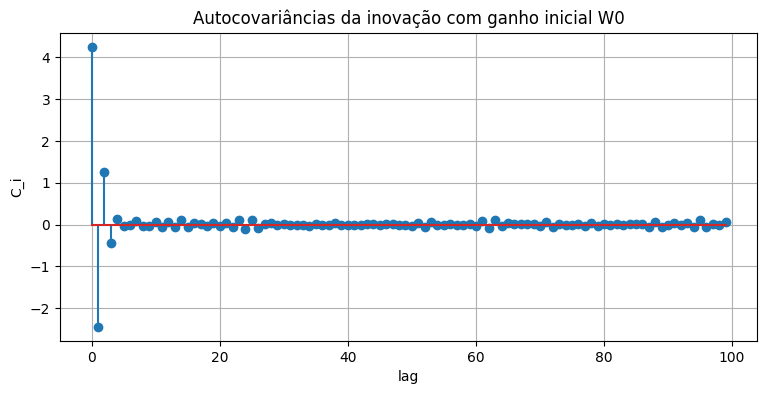

In [131]:
plt.figure(figsize=(9, 4))
plt.stem(range(M), C0)
plt.title("Autocovariâncias da inovação com ganho inicial W0")
plt.xlabel("lag")
plt.ylabel("C_i")
plt.show()

## 6. Função custo dependente de $W$

1. rodamos o filtro
2. coletamos a sequência de inovações
3. estimamos as autocovariâncias
4. calculamos $J(W)$

Penalização se a matriz fechada

$$
\bar{F} = F(I - WH)
$$

ficar muito próxima da instabilidade

In [ ]:
def spectral_radius(A):
    return max(abs(eigvals(A)))

def J_for_W_scalar(W_vec, F, H, z, M, burn_in=300):
    n = F.shape[0]
    W = np.asarray(W_vec, dtype=float).reshape(n, 1)

    Fbar = F @ (np.eye(n) - W @ H)
    rho = spectral_radius(Fbar)

    if rho >= 0.999:
        # Penalidade
        return 1e6 + 1e4 * (rho - 0.999 + 1.0)

    _, _, nu, _ = run_filter_scalar(F, H, W, z)
    nu = nu[burn_in:]

    C = innovation_covariances_scalar(nu, M)
    J = objective_J_scalar(C)

    return float(J + 1e-4 * rho)

print("J(W0) via função completa =", J_for_W_scalar(W0.ravel(), F, H, z, M))

J(W0) via função completa = 0.2200844008455968


## 7. Busca do ganho $W$ por descida com passo adaptativo

O artigo-base usa uma atualização iterativa:

- calcula o gradiente numérico
- dá um passo na direção de descida
- se a função melhora, aumenta um pouco o passo
- se piora, reduz o passo

In [133]:
def numerical_grad(f, x, eps=1e-4):
    x = np.asarray(x, dtype=float).copy()
    g = np.zeros_like(x)

    for i in range(len(x)):
        h = eps * (1.0 + abs(x[i]))
        xp = x.copy()
        xm = x.copy()
        xp[i] += h
        xm[i] -= h
        g[i] = (f(xp) - f(xm)) / (2.0 * h)

    return g

def bold_driver_optimize_W(
    F,
    H,
    z,
    W0,
    M=40,
    max_iter=100,
    alpha0=0.08,
    patience=12,
    tol_grad=1e-6,
    tol_step=1e-6,
):
    W = np.asarray(W0, dtype=float).reshape(-1)
    alpha = alpha0

    f = lambda w: J_for_W_scalar(w, F, H, z, M)
    J = f(W)

    best_W = W.copy()
    best_J = J

    hist = [{"iter": 0, "J": J, "alpha": alpha, "W": W.copy()}]
    bad_streak = 0

    for it in range(1, max_iter + 1):
        g = numerical_grad(f, W)

        if norm(g) < tol_grad:
            hist.append({"iter": it, "J": J, "alpha": alpha, "W": W.copy()})
            break

        improved = False
        local_alpha = alpha

        for _ in range(25):
            cand = W - local_alpha * g
            J_cand = f(cand)

            if J_cand < J:
                improved = True
                step_norm = norm(cand - W)

                W, J = cand, J_cand
                alpha = min(1.1 * local_alpha, 0.5)
                bad_streak = 0

                if J < best_J:
                    best_W = W.copy()
                    best_J = J

                hist.append({"iter": it, "J": J, "alpha": alpha, "W": W.copy()})

                if step_norm < tol_step:
                    return best_W.reshape(F.shape[0], 1), hist

                break

            local_alpha *= 0.5

        if not improved:
            alpha = max(local_alpha, 1e-8)
            bad_streak += 1
            hist.append({"iter": it, "J": J, "alpha": alpha, "W": W.copy()})

            if bad_streak >= patience:
                break

    return best_W.reshape(F.shape[0], 1), hist

In [134]:
W_est, hist = bold_driver_optimize_W(F, H, z, W0, M=M)

J_hist = [item["J"] for item in hist]
W_hist = np.array([item["W"] for item in hist])

print("W inicial =\n", W0)
print("\nW estimado =\n", W_est)
print("\nW verdadeiro =\n", W_true)
print("\nJ inicial =", J_hist[0])
print("J final    =", J_hist[-1])
print("Número de registros no histórico:", len(hist))

W inicial =
 [[0.9]
 [0.5]]

W estimado =
 [[0.6462]
 [0.1073]]

W verdadeiro =
 [[0.6542]
 [0.0883]]

J inicial = 0.2200844008455968
J final    = 0.004459875330835009
Número de registros no histórico: 101


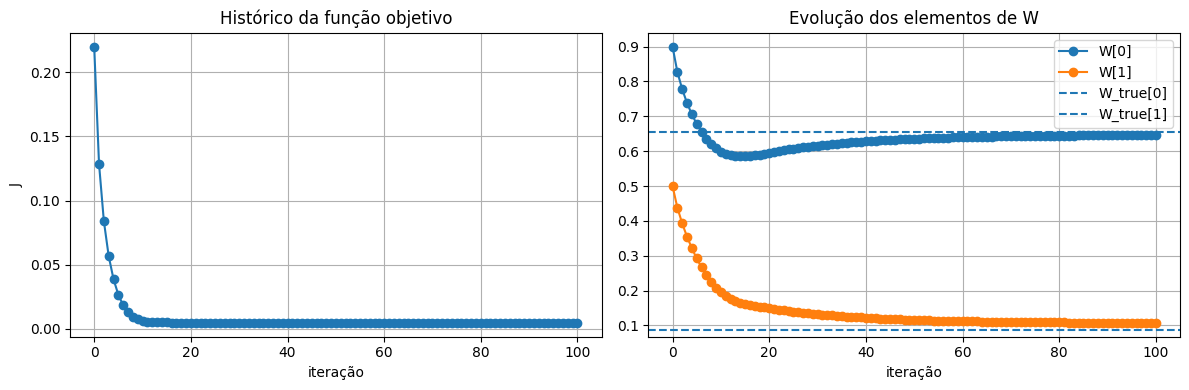

In [135]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(J_hist, marker="o")
ax[0].set_title("Histórico da função objetivo")
ax[0].set_xlabel("iteração")
ax[0].set_ylabel("J")

ax[1].plot(W_hist[:, 0], marker="o", label="W[0]")
ax[1].plot(W_hist[:, 1], marker="o", label="W[1]")
ax[1].axhline(W_true[0, 0], linestyle="--", label="W_true[0]")
ax[1].axhline(W_true[1, 0], linestyle="--", label="W_true[1]")
ax[1].set_title("Evolução dos elementos de W")
ax[1].set_xlabel("iteração")
ax[1].legend()

plt.tight_layout()
plt.show()

## 8. Estimação de $R$ usando os post-fit residuals

Depois de obter $W$, o artigo-base propõe várias formas de estimar $R$

Como neste caso a medição é escalar, vamos por R3

Do artigo:

$$
G = R S^{-1} R
$$

No caso escalar:

$$
G = \frac{R^2}{S}
\quad \Longrightarrow \quad
R = \sqrt{G\,S}
$$

onde:

- $S = \mathbb E[
u_k^2]$: variância da inovação;
- $G = \mathbb E[\mu_k^2]$: variância do post-fit residual.

E a forma R1:

$$
R = (1 - HW)S
$$

No caso escalar, as duas devem coincidir

In [ ]:
def estimate_R_scalar(W, H, nu, mu):
    S = float(np.mean(nu ** 2))
    G = float(np.mean(mu ** 2))

    # Método R3 do artigo, simplificado para o caso escalar:
    R3 = math.sqrt(max(G * S, 1e-12))

    # Método R1 do artigo, também escalar:
    HW = float((H @ W)[0, 0])
    R1 = (1.0 - HW) * S

    return {"S": S, "G": G, "R1": R1, "R3": R3}

_, _, nu_est, mu_est = run_filter_scalar(F, H, W_est, z)

burn_in = 500
nu_b = nu_est[burn_in:]
mu_b = mu_est[burn_in:]

R_info = estimate_R_scalar(W_est, H, nu_b, mu_b)

print("S estimado =", R_info["S"])
print("G estimado =", R_info["G"])
print("R1         =", R_info["R1"])
print("R3         =", R_info["R3"])
print("R verdadeiro =", r_true)

S estimado = 2.829912152275616
G estimado = 0.35429283935044276
R1         = 1.0013079504038958
R3         = 1.0013079504038958
R verdadeiro = 1.0


## 9. Estimação iterativa de $q$ e $P$

Como o ruído de processo é escalar e entra via $\Gamma$, vamos estimar:

$$
Q_x = \Gamma q \Gamma^	op
$$

A ideia é:

1. inicializar $q$;
2. iterar uma equação fixa para $P$;
3. atualizar $q$ a partir da matriz
   $$
   D = P + WSW^	op - FPF^	op
   
$$
4. repetir até convergir

In [ ]:
def initial_q_from_WSW(W, S, Gamma):
    D0 = W @ np.array([[S]]) @ W.T
    Gpinv = pinv(Gamma)
    q0 = float((Gpinv @ D0 @ Gpinv.T)[0, 0])
    return max(q0, 1e-9)

def estimate_q_and_P_iterative(F, H, Gamma, W, S, R, max_outer=100, max_inner=500, tol=1e-12):
    n = F.shape[0]
    q = initial_q_from_WSW(W, S, Gamma)
    Gpinv = pinv(Gamma)
    P = np.eye(n)

    q_hist = [q]

    for _ in range(max_outer):
        Qterm = Gamma @ np.array([[q]]) @ Gamma.T
        P_inner = P.copy()

        # iteração interna para P
        for _ in range(max_inner):
            Mmat = F @ P_inner @ F.T + Qterm
            P_next = inv(inv(Mmat) + H.T @ np.array([[1.0 / R]]) @ H)

            if norm(P_next - P_inner) < tol:
                P_inner = P_next
                break

            P_inner = P_next

        P = P_inner

        D = P + W @ np.array([[S]]) @ W.T - F @ P @ F.T
        q_new = float((Gpinv @ D @ Gpinv.T)[0, 0])
        q_new = max(q_new, 1e-9)

        q_hist.append(q_new)

        if abs(q_new - q) < 1e-10:
            q = q_new
            break

        q = q_new

    return q, P, q_hist

q_est, P_est, q_hist = estimate_q_and_P_iterative(
    F=F,
    H=H,
    Gamma=Gamma,
    W=W_est,
    S=R_info["S"],
    R=R_info["R3"],
)

print("q inicial projetado =", q_hist[0])
print("q final estimado    =", q_est)
print("q verdadeiro        =", q_true)
print("\nP estimado =\n", P_est)

q inicial projetado = 0.8869668141741178
q final estimado    = 0.9850571854900763
q verdadeiro        = 1.0

P estimado =
 [[0.6522 0.0869]
 [0.0869 0.329 ]]


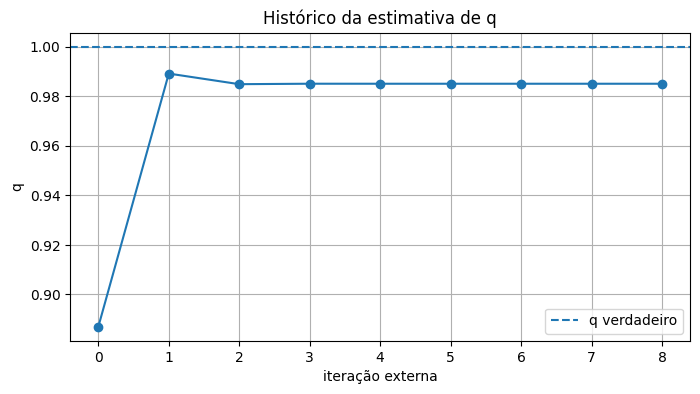

In [138]:
plt.figure(figsize=(8, 4))
plt.plot(q_hist, marker="o")
plt.axhline(q_true, linestyle="--", label="q verdadeiro")
plt.title("Histórico da estimativa de q")
plt.xlabel("iteração externa")
plt.ylabel("q")
plt.legend()
plt.show()

## 10. Diagnósticos

Vamos checar:

1. **média da inovação**;
2. **média da inovação branqueada**;
3. **autocorrelação da inovação branqueada**;
4. **NIS** e a sua média.

In [ ]:
def whitened_innovation(nu, S):
    return nu / math.sqrt(S)

def autocorrelation_lags(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    denom = np.dot(x, x)
    ac = [1.0]
    for lag in range(1, max_lag + 1):
        ac.append(float(np.dot(x[lag:], x[:-lag]) / denom))
    return np.array(ac)

e = whitened_innovation(nu_b, R_info["S"])
nis = (nu_b ** 2) / R_info["S"]

print("Média da inovação            =", np.mean(nu_b))
print("Variância da inovação        =", np.var(nu_b))
print("Média da inovação branca     =", np.mean(e))
print("Variância da inovação branca =", np.var(e))
print("Média do NIS                 =", np.mean(nis))
print("Valor esperado do NIS        = 1.0")

Média da inovação            = 0.023295425789952015
Variância da inovação        = 2.829369475412881
Média da inovação branca     = 0.013847908196507677
Variância da inovação branca = 0.9998082354385812
Média do NIS                 = 1.0
Valor esperado do NIS        = 1.0


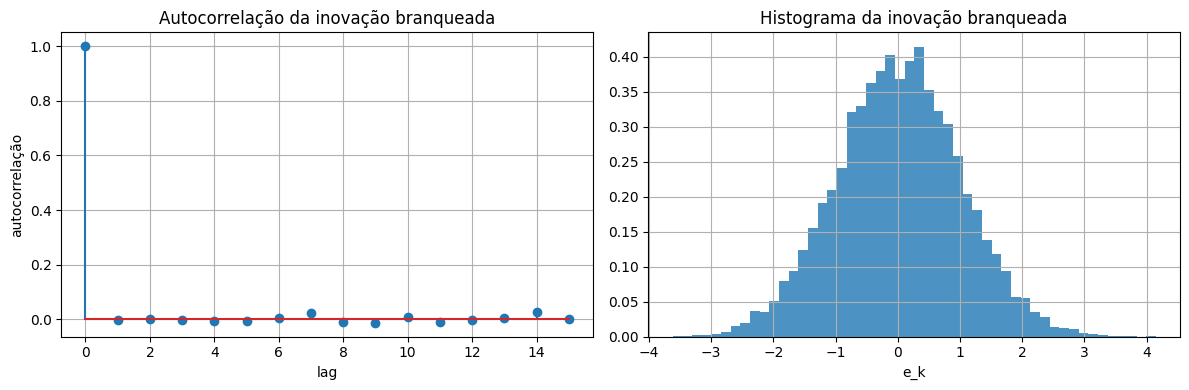

In [140]:
max_lag = 15
ac = autocorrelation_lags(e, max_lag)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].stem(range(max_lag + 1), ac)
ax[0].set_title("Autocorrelação da inovação branqueada")
ax[0].set_xlabel("lag")
ax[0].set_ylabel("autocorrelação")

ax[1].hist(e, bins=50, density=True, alpha=0.8)
ax[1].set_title("Histograma da inovação branqueada")
ax[1].set_xlabel("e_k")

plt.tight_layout()
plt.show()

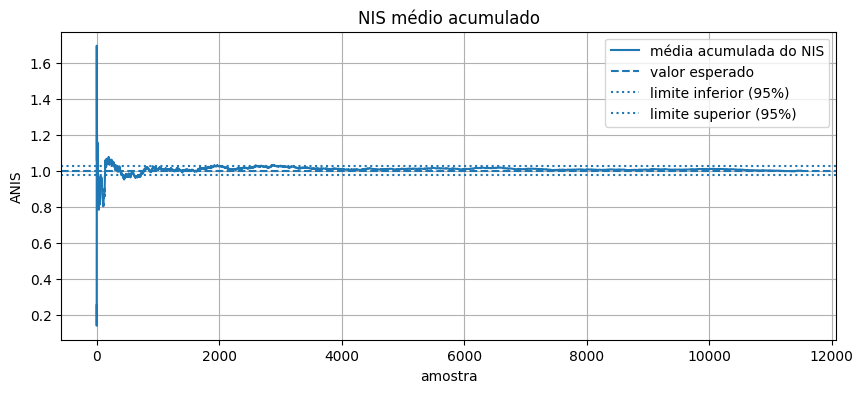

In [141]:
alpha = 0.05
N_nis = len(nis)

lower_avg = chi2.ppf(alpha / 2, df=N_nis) / N_nis
upper_avg = chi2.ppf(1 - alpha / 2, df=N_nis) / N_nis

running_avg_nis = np.cumsum(nis) / np.arange(1, len(nis) + 1)

plt.figure(figsize=(10, 4))
plt.plot(running_avg_nis, label="média acumulada do NIS")
plt.axhline(1.0, linestyle="--", label="valor esperado")
plt.axhline(lower_avg, linestyle=":", label="limite inferior (95%)")
plt.axhline(upper_avg, linestyle=":", label="limite superior (95%)")
plt.title("NIS médio acumulado")
plt.xlabel("amostra")
plt.ylabel("ANIS")
plt.legend()
plt.show()

## 11. Resumo numérico

Resumo dos principais números estimados e comparação com os valores verdadeiros

In [142]:
summary = pd.DataFrame(
    {
        "parâmetro": ["W[0]", "W[1]", "R", "q", "S", "média do NIS"],
        "estimado": [
            float(W_est[0, 0]),
            float(W_est[1, 0]),
            float(R_info["R3"]),
            float(q_est),
            float(R_info["S"]),
            float(np.mean(nis)),
        ],
        "verdadeiro / referência": [
            float(W_true[0, 0]),
            float(W_true[1, 0]),
            r_true,
            q_true,
            float(S_true[0, 0]),
            1.0,
        ],
    }
)

summary["erro absoluto"] = np.abs(summary["estimado"] - summary["verdadeiro / referência"])
summary

,parâmetro,estimado,verdadeiro / referência,erro absoluto
0,W[0],0.646170,0.654230,0.008061
1,W[1],0.107271,0.088286,0.018985
2,R,1.001308,1.000000,0.001308
3,q,0.985057,1.000000,0.014943
4,S,2.829912,2.892100,0.062188
5,média do NIS,1.000000,1.000000,0.000000


## 12. Conclusão

### O que foi feito
- validação inicial do método no **Case 2** linear
- estimação do ganho estacionário $W$ a partir da brancura da inovação
- estimação de $R$ via post-fit residual
- estimação de $q$ iterativamente
- verificação dos diagnósticos de consistência

### O que isso mostra
Se os resultados numéricos ficaram próximos dos valores verdadeiros e os diagnósticos da inovação ficaram razoáveis, então o **método está ok**


## 13. NEES no caso atual

**NEES** é definido por:

$$
\epsilon_{x,k} = \tilde x_{k|k}^\top P_{k|k}^{-1}\tilde x_{k|k}
$$

onde:

- $\tilde x_{k|k} = x_k - \hat x_{k|k}$ é o erro de estimação atualizado
- $P_{k|k}$ é a covariância atualizada usada pelo filtro

### Interpretação
Se o filtro estiver consistente e o modelo bem ajustado:

- a média da NEES deve ser aproximadamente igual ao número de estados $n$;
- como $n=2$, o valor esperado é **2**


In [143]:

def compute_nees_from_run(x_true, x_upd_hist, P):
    P_inv = np.linalg.inv(P)
    ex = x_true - x_upd_hist
    nees = np.einsum("bi,ij,bj->b", ex, P_inv, ex)
    return ex, nees

x_pred_est, x_upd_est, nu_est_full, mu_est_full = run_filter_scalar(F, H, W_est, z)

# NEES usando P estimado
ex_full, nees_full = compute_nees_from_run(x_true, x_upd_est, P_est)

nees_b = nees_full[burn_in:]
ex_b = ex_full[burn_in:]

print("Média da NEES =", np.mean(nees_b))
print("Valor esperado da NEES =", F.shape[0])
print("Variâncias empíricas do erro de estado atualizado:")
print(np.var(ex_b, axis=0))
print("\nDiagonal de P_est:")
print(np.diag(P_est))


Média da NEES = 2.0564306733553837
Valor esperado da NEES = 2
Variâncias empíricas do erro de estado atualizado:
[0.6683 0.3383]

Diagonal de P_est:
[0.6522 0.329 ]


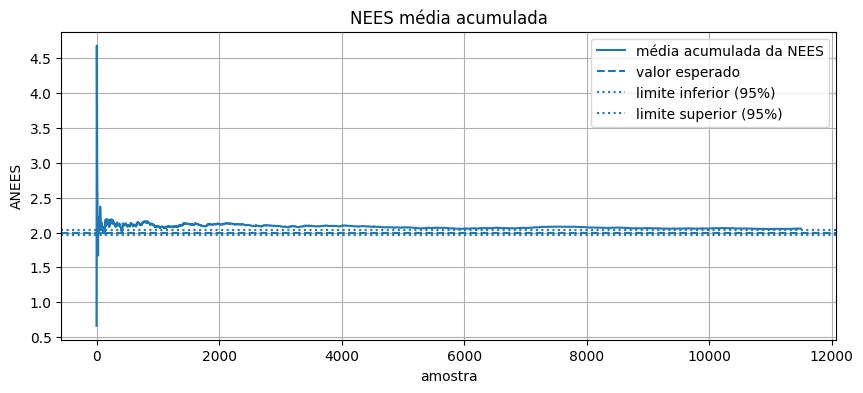

In [144]:

alpha = 0.05
n_state = F.shape[0]
N_nees = len(nees_b)

lower_nees_avg = chi2.ppf(alpha / 2, df=N_nees * n_state) / N_nees
upper_nees_avg = chi2.ppf(1 - alpha / 2, df=N_nees * n_state) / N_nees
running_avg_nees = np.cumsum(nees_b) / np.arange(1, len(nees_b) + 1)

plt.figure(figsize=(10, 4))
plt.plot(running_avg_nees, label="média acumulada da NEES")
plt.axhline(n_state, linestyle="--", label="valor esperado")
plt.axhline(lower_nees_avg, linestyle=":", label="limite inferior (95%)")
plt.axhline(upper_nees_avg, linestyle=":", label="limite superior (95%)")
plt.title("NEES média acumulada")
plt.xlabel("amostra")
plt.ylabel("ANEES")
plt.legend()
plt.show()



## 14. Validação Monte Carlo do filtro identificado

- manter o filtro já identificado $(W_{\text{est}}, R_{\text{est}}, q_{\text{est}}, P_{\text{est}}, S_{\text{est}})$
- gerar várias novas trajetorias independentes do sistema verdadeiro
- rodar o filtro em cada uma delas
- calcular **NIS** e **NEES** em cada execução
- observar as médias acumuladas e as distribuições finais


In [ ]:

def evaluate_fixed_filter_mc(
    F, Gamma, H,
    q_true, r_true,
    W_fixed, P_fixed, S_fixed,
    N, n_runs, seed=2026
):
    rng_local = np.random.default_rng(seed)

    anis_runs = []
    anees_runs = []
    nis_mean_runs = []
    nees_mean_runs = []
    R1_runs = []
    q_runs = []

    nis_all = np.zeros((n_runs, N))
    nees_all = np.zeros((n_runs, N))

    for i in range(n_runs):
        x_mc, z_mc = simulate_linear_system(F, Gamma, H, q_true, r_true, N, rng_local)
        _, x_upd_mc, nu_mc, mu_mc = run_filter_scalar(F, H, W_fixed, z_mc)

        _, nees_mc = compute_nees_from_run(x_mc, x_upd_mc, P_fixed)
        nis_mc = (nu_mc ** 2) / S_fixed

        nis_all[i] = nis_mc
        nees_all[i] = nees_mc

        anis_runs.append(np.cumsum(nis_mc) / np.arange(1, N + 1))
        anees_runs.append(np.cumsum(nees_mc) / np.arange(1, N + 1))
        nis_mean_runs.append(np.mean(nis_mc))
        nees_mean_runs.append(np.mean(nees_mc))

    anis_runs = np.array(anis_runs)
    anees_runs = np.array(anees_runs)

    return {
        "nis_all": nis_all,
        "nees_all": nees_all,
        "anis_runs": anis_runs,
        "anees_runs": anees_runs,
        "nis_mean_runs": np.array(nis_mean_runs),
        "nees_mean_runs": np.array(nees_mean_runs),
    }

n_mc_runs = 100
N_mc = 1000

mc = evaluate_fixed_filter_mc(
    F=F,
    Gamma=Gamma,
    H=H,
    q_true=q_true,
    r_true=r_true,
    W_fixed=W_est,
    P_fixed=P_est,
    S_fixed=R_info["S"],
    N=N_mc,
    n_runs=n_mc_runs,
    seed=2026,
)

print("Número de rodadas Monte Carlo:", n_mc_runs)
print("Comprimento de cada rodada:", N_mc)
print("Média das médias NIS  :", np.mean(mc["nis_mean_runs"]))
print("Média das médias NEES :", np.mean(mc["nees_mean_runs"]))


Número de rodadas Monte Carlo: 100
Comprimento de cada rodada: 1000
Média das médias NIS  : 1.0180422438988477
Média das médias NEES : 2.008095738513107


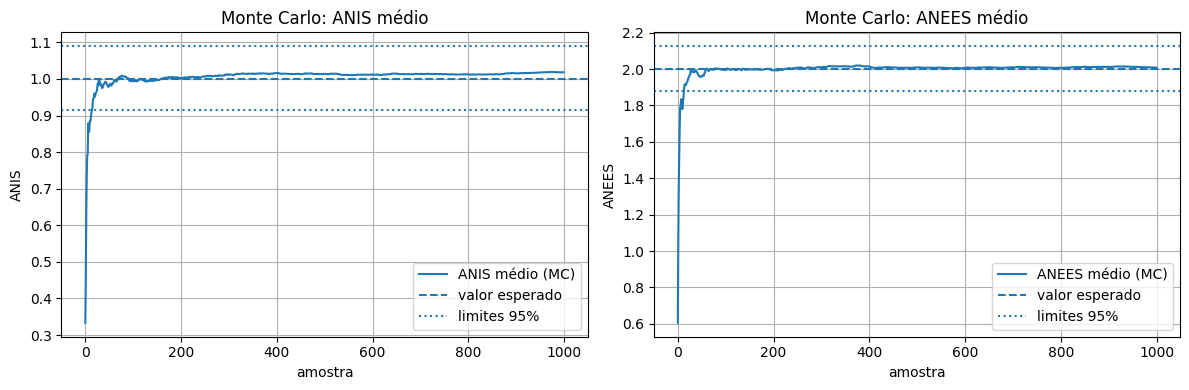

In [146]:

m_meas = 1
n_state = F.shape[0]

nis_lower_mc = chi2.ppf(alpha / 2, df=N_mc * m_meas) / N_mc
nis_upper_mc = chi2.ppf(1 - alpha / 2, df=N_mc * m_meas) / N_mc

nees_lower_mc = chi2.ppf(alpha / 2, df=N_mc * n_state) / N_mc
nees_upper_mc = chi2.ppf(1 - alpha / 2, df=N_mc * n_state) / N_mc

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# ANIS médio
ax[0].plot(np.mean(mc["anis_runs"], axis=0), label="ANIS médio (MC)")
ax[0].axhline(m_meas, linestyle="--", label="valor esperado")
ax[0].axhline(nis_lower_mc, linestyle=":", label="limites 95%")
ax[0].axhline(nis_upper_mc, linestyle=":")
ax[0].set_title("Monte Carlo: ANIS médio")
ax[0].set_xlabel("amostra")
ax[0].set_ylabel("ANIS")
ax[0].legend()

# ANEES médio
ax[1].plot(np.mean(mc["anees_runs"], axis=0), label="ANEES médio (MC)")
ax[1].axhline(n_state, linestyle="--", label="valor esperado")
ax[1].axhline(nees_lower_mc, linestyle=":", label="limites 95%")
ax[1].axhline(nees_upper_mc, linestyle=":")
ax[1].set_title("Monte Carlo: ANEES médio")
ax[1].set_xlabel("amostra")
ax[1].set_ylabel("ANEES")
ax[1].legend()

plt.tight_layout()
plt.show()


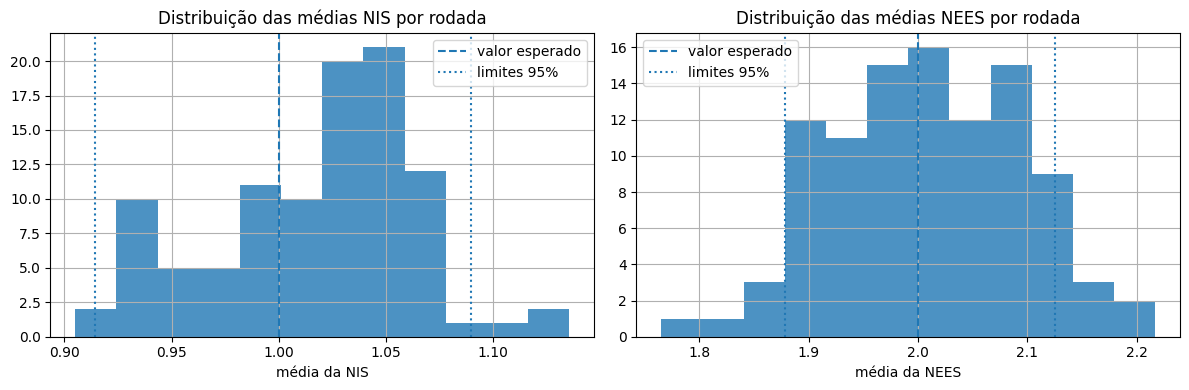

In [147]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(mc["nis_mean_runs"], bins=12, alpha=0.8)
ax[0].axvline(m_meas, linestyle="--", label="valor esperado")
ax[0].axvline(nis_lower_mc, linestyle=":", label="limites 95%")
ax[0].axvline(nis_upper_mc, linestyle=":")
ax[0].set_title("Distribuição das médias NIS por rodada")
ax[0].set_xlabel("média da NIS")
ax[0].legend()

ax[1].hist(mc["nees_mean_runs"], bins=12, alpha=0.8)
ax[1].axvline(n_state, linestyle="--", label="valor esperado")
ax[1].axvline(nees_lower_mc, linestyle=":", label="limites 95%")
ax[1].axvline(nees_upper_mc, linestyle=":")
ax[1].set_title("Distribuição das médias NEES por rodada")
ax[1].set_xlabel("média da NEES")
ax[1].legend()

plt.tight_layout()
plt.show()


In [148]:

summary_mc = pd.DataFrame(
    {
        "métrica": [
            "média das médias NIS (MC)",
            "média das médias NEES (MC)",
            "limite inferior NIS (95%)",
            "limite superior NIS (95%)",
            "limite inferior NEES (95%)",
            "limite superior NEES (95%)",
        ],
        "valor": [
            float(np.mean(mc["nis_mean_runs"])),
            float(np.mean(mc["nees_mean_runs"])),
            float(nis_lower_mc),
            float(nis_upper_mc),
            float(nees_lower_mc),
            float(nees_upper_mc),
        ],
    }
)
summary_mc


,métrica,valor
0,média das médias NIS (MC),1.018042
1,média das médias NEES (MC),2.008096
2,limite inferior NIS (95%),0.914257
3,limite superior NIS (95%),1.089531
4,limite inferior NEES (95%),1.877946
5,limite superior NEES (95%),2.125842
